In [82]:
from random import random

from pandas.core.common import random_state
from requests.packages import target

pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import os

os.system("kaggle - version")

1

In [58]:
!kaggle datasets download -d kartik2112/fraud-detection

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [59]:
import zipfile

with zipfile.ZipFile("fraud-detection.zip", "r") as zip_ref:
    zip_ref.extractall("fraud_detection")

print("Extraction completed!")

Extraction completed!


In [60]:
import os
print(os.getcwd())
print(os.listdir())
print(os.listdir("fraud_detection"))

C:\Users\Rushabh\PycharmProjects\PythonProject4\.venv
['.gitignore', 'CACHEDIR.TAG', 'code.ipynb', 'etc', 'fraud-detection.zip', 'fraud_detection', 'Lib', 'pyvenv.cfg', 'Scripts', 'share']
['fraudTest.csv', 'fraudTrain.csv']


In [83]:
import pandas as pd

train_df = pd.read_csv("fraud_detection/fraudTrain.csv")
test_df = pd.read_csv("fraud_detection/fraudTest.csv")

print(train_df.head())
print(test_df.head())
print(train_df.shape)
print(test_df.shape)
print(train_df['is_fraud'].value_counts())
print(train_df['category'].value_counts())
print(train_df.isnull().sum().sum())


   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

In [84]:
fraud_by_cat = train_df.groupby('category')['is_fraud'].agg(['mean','count']).sort_values('mean', ascending=False)
print(fraud_by_cat)

print(train_df.groupby('is_fraud')['amt'].describe())

                    mean   count
category                        
shopping_net    0.017561   97543
misc_net        0.014458   63287
grocery_pos     0.014098  123638
shopping_pos    0.007225  116672
gas_transport   0.004694  131659
misc_pos        0.003139   79655
grocery_net     0.002948   45452
travel          0.002864   40507
entertainment   0.002478   94014
personal_care   0.002424   90758
kids_pets       0.002114  113035
food_dining     0.001651   91461
home            0.001608  123115
health_fitness  0.001549   85879
              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


Feature Scaling[ harversine_distance]

In [85]:
import numpy as np

def harversine_distance(lat1,lon1,lat2,lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    R = 3959
    distance = R  * c
    return distance


Apply it to your whole dataframe at once

In [86]:
train_df['distance'] = harversine_distance(train_df['lat'],train_df['long'],train_df['merch_lat'],train_df['merch_long'])

print(train_df.describe())

         Unnamed: 0        cc_num           amt           zip           lat  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   6.483370e+05  4.171920e+17  7.035104e+01  4.880067e+04  3.853762e+01   
std    3.743180e+05  1.308806e+18  1.603160e+02  2.689322e+04  5.075808e+00   
min    0.000000e+00  6.041621e+10  1.000000e+00  1.257000e+03  2.002710e+01   
25%    3.241685e+05  1.800429e+14  9.650000e+00  2.623700e+04  3.462050e+01   
50%    6.483370e+05  3.521417e+15  4.752000e+01  4.817400e+04  3.935430e+01   
75%    9.725055e+05  4.642255e+15  8.314000e+01  7.204200e+04  4.194040e+01   
max    1.296674e+06  4.992346e+18  2.894890e+04  9.978300e+04  6.669330e+01   

               long      city_pop     unix_time     merch_lat    merch_long  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean  -9.022634e+01  8.882444e+04  1.349244e+09  3.853734e+01 -9.022646e+01   
std    1.375908e+01  3.019564e+05  1.284128e+07  5.

In [87]:
print(train_df.groupby('is_fraud')['distance'].describe())

              count       mean        std       min        25%        50%  \
is_fraud                                                                    
0         1289169.0  47.297812  18.094855  0.013829  34.384266  48.614738   
1            7506.0  47.393865  17.867140  0.459078  34.570807  48.427658   

                75%        max  
is_fraud                        
0         61.211632  94.527058  
1         61.141159  89.807600  


Distance didnt play a important tole int the dataset

In [88]:
train_df['dob'] = pd.to_datetime(train_df['dob'])
train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])

train_df['age'] = (train_df['trans_date_trans_time'] - train_df['dob']).dt.days // 365

In [89]:
print(train_df['age'].describe())
print(train_df.groupby('is_fraud')['age'].describe())

count    1.296675e+06
mean     4.552822e+01
std      1.740895e+01
min      1.300000e+01
25%      3.200000e+01
50%      4.400000e+01
75%      5.700000e+01
max      9.500000e+01
Name: age, dtype: float64
              count       mean        std   min   25%   50%   75%   max
is_fraud                                                               
0         1289169.0  45.511960  17.398818  13.0  32.0  43.0  57.0  95.0
1            7506.0  48.321609  18.864543  14.0  33.0  47.0  60.0  93.0


Age Gap also not played imoortant role

In [90]:
train_df['hour'] = train_df['trans_date_trans_time'].dt.hour
train_df['day_of_week'] = train_df['trans_date_trans_time'].dt.dayofweek

In [91]:
print(train_df.groupby('is_fraud')['hour'].describe())
print(train_df.groupby('is_fraud')['day_of_week'].describe())

              count       mean       std  min  25%   50%   75%   max
is_fraud                                                            
0         1289169.0  12.797679  6.796797  0.0  7.0  14.0  19.0  23.0
1            7506.0  14.037836  9.702306  0.0  2.0  22.0  23.0  23.0
              count      mean       std  min  25%  50%  75%  max
is_fraud                                                        
0         1289169.0  3.070312  2.198892  0.0  1.0  3.0  5.0  6.0
1            7506.0  3.120703  2.066794  0.0  1.0  3.0  5.0  6.0


In [92]:
test_df['distance'] = harversine_distance(test_df['lat'],test_df['long'],test_df['merch_lat'],test_df['merch_long'])

test_df['dob'] = pd.to_datetime(test_df['dob'])
test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])
test_df['age'] = (test_df['trans_date_trans_time'] - test_df['dob']).dt.days // 365


test_df['hour'] = test_df['trans_date_trans_time'].dt.hour

test_df['day_of_week'] = test_df['trans_date_trans_time'].dt.dayofweek

print(test_df[['distance','age','hour','day_of_week']].describe())

            distance            age           hour    day_of_week
count  555719.000000  555719.000000  555719.000000  555719.000000
mean       47.292310      46.423797      12.809062       2.726779
std        18.093630      17.442737       6.810924       2.178681
min         0.076982      15.000000       0.000000       0.000000
25%        34.355405      33.000000       7.000000       1.000000
50%        48.581495      44.000000      14.000000       2.000000
75%        61.221738      58.000000      19.000000       5.000000
max        93.784680      96.000000      23.000000       6.000000


Droping the cols which are not important

In [94]:
drop_cols = [
    'Unnamed: 0',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num',
    'dob',
    'trans_date_trans_time',
    'unix_time'
]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print(train_df.columns.tolist())
print(train_df.shape)

KeyError: "['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num', 'dob', 'trans_date_trans_time', 'unix_time'] not found in axis"

Finding the unquie count

In [72]:
for col in ['merchant','category','gender','city','state','job']:
    print(col, train_df[col].nunique())

merchant 693
category 14
gender 2
city 894
state 51
job 494


Droping the cols after finding unique count

In [73]:
print(train_df["gender"].value_counts(dropna=False))

gender
F    709863
M    586812
Name: count, dtype: int64


In [74]:
print(train_df.columns.tolist())
print(train_df.shape)
train_df.head()

['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'distance', 'age', 'hour', 'day_of_week']
(1296675, 18)


,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,distance,age,hour,day_of_week
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,48.841277,30,0,1
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,18.774133,40,0,1
2,fraud_Lind-Buckridge,entertainment,220.11,M,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,67.240289,56,0,1
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071,0,59.452256,52,0,1
4,fraud_Keeling-Crist,misc_pos,41.96,M,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459,0,48.194498,32,0,1


In [75]:
print(test_df.columns.tolist())
print(test_df.shape)

['merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'distance', 'age', 'hour', 'day_of_week']
(555719, 18)


Spliting features and target

In [76]:
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1296675, 17) (1296675,)
(555719, 17) (555719,)


FileNotFoundError: [Errno 2] No such file or directory: 'fraudTrain.csv'

ML MODEL

In [78]:
import sklearn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'fraud_Rippin, Kub and Mann'

In [79]:
print(X_train.dtypes)

merchant           str
category           str
amt            float64
gender             str
city               str
state              str
zip              int64
lat            float64
long           float64
city_pop         int64
job                str
merch_lat      float64
merch_long     float64
distance       float64
age              int64
hour             int32
day_of_week      int32
dtype: object


In [2]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Rushabh\PycharmProjects\PythonProject4\.venv
['.gitignore', 'CACHEDIR.TAG', 'code.ipynb', 'etc', 'fraud-detection.zip', 'fraud_detection', 'Lib', 'pyvenv.cfg', 'Scripts', 'share']


In [3]:
print(os.listdir('fraud_detection'))

['fraudTest.csv', 'fraudTrain.csv']


In [4]:
train_df = pd.read_csv('fraud_detection/fraudTrain.csv')
test_df = pd.read_csv('fraud_detection/fraudTest.csv')

In [5]:
import pandas as pd
import numpy as np

# Load data fresh
train_df = pd.read_csv('fraud_detection/fraudTrain.csv')
test_df = pd.read_csv('fraud_detection/fraudTest.csv')

# Haversine distance function
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    R = 3959
    return R * c

for df in [train_df, test_df]:
    df['distance'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# Drop junk columns
drop_cols = ['Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'trans_num',
             'dob', 'trans_date_trans_time', 'unix_time',
             'merchant', 'city', 'job', 'state', 'zip']
train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

# Encode gender
train_df['gender'] = train_df['gender'].map({'M': 1, 'F': 0})
test_df['gender'] = test_df['gender'].map({'M': 1, 'F': 0})

# One-hot encode category
train_df = pd.get_dummies(train_df, columns=['category'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['category'], drop_first=True)

# Confirm clean
print(train_df.dtypes)
print(train_df.shape, test_df.shape)

amt                        float64
gender                       int64
lat                        float64
long                       float64
city_pop                     int64
merch_lat                  float64
merch_long                 float64
is_fraud                     int64
distance                   float64
age                          int64
hour                         int32
day_of_week                  int32
category_food_dining          bool
category_gas_transport        bool
category_grocery_net          bool
category_grocery_pos          bool
category_health_fitness       bool
category_home                 bool
category_kids_pets            bool
category_misc_net             bool
category_misc_pos             bool
category_personal_care        bool
category_shopping_net         bool
category_shopping_pos         bool
category_travel               bool
dtype: object
(1296675, 25) (555719, 25)


In [6]:
# Split X and y
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1296675, 24) (1296675,)
(555719, 24) (555719,)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Training model")

Training model


In [9]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94    553574
           1       0.02      0.74      0.04      2145

    accuracy                           0.88    555719
   macro avg       0.51      0.81      0.49    555719
weighted avg       1.00      0.88      0.93    555719

[[486548  67026]
 [   556   1589]]


True Negatives: 486,548 — legit transactions correctly identified as legit
False Positives: 67,026 — legit transactions wrongly flagged as fraud
False Negatives: 556 — actual fraud the model missed
True Positives: 1,589 — actual fraud correctly caught

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth = 120,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Training done")

Training done


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.90      0.78      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.89      0.92    555719
weighted avg       1.00      1.00      1.00    555719

[[553388    186]
 [   478   1667]]


 Random Forest kept recall roughly similar (78% vs 74% — still catching most fraud), but precision went from useless (2%) to genuinely strong (90%). Look at the confusion matrix: only 186 false positives now, compared to 67,026 before. That's a ~360x reduction in wrongly-flagged legitimate transactions, while actually catching more real fraud (1,667 vs 1,589).

feature importance

In [13]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_test.columns)
importances = importances.sort_values(ascending=False)
print(importances)

amt                        0.548791
hour                       0.196110
age                        0.025787
category_gas_transport     0.025009
category_shopping_net      0.021323
category_grocery_pos       0.017090
city_pop                   0.016250
merch_lat                  0.013136
merch_long                 0.012699
distance                   0.012271
lat                        0.011569
long                       0.010917
category_home              0.010448
category_food_dining       0.010023
category_misc_net          0.009232
category_shopping_pos      0.008088
category_misc_pos          0.007324
category_travel            0.007294
gender                     0.007278
category_grocery_net       0.006845
day_of_week                0.006492
category_kids_pets         0.006398
category_health_fitness    0.005153
category_personal_care     0.004473
dtype: float64


In [19]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [25]:

from xgboost import XGBClassifier

# Handle imbalance via scale_pos_weight instead of class_weight
# (XGBoost's equivalent — ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

print("Training done")

scale_pos_weight: 171.75179856115108
Training done


In [26]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.34      0.92      0.49      2145

    accuracy                           0.99    555719
   macro avg       0.67      0.96      0.74    555719
weighted avg       1.00      0.99      0.99    555719

[[549662   3912]
 [   167   1978]]


XGBoost with scale_pos_weight catches the most fraud by far (92% recall, 1,978 out of 2,145 actual fraud cases), but at the cost of far more false alarms than Random Forest (3,912 vs 186). By F1-score, Random Forest is still the better balanced model (0.83 vs 0.49).

In [29]:
xgb_model_v2 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=15, # much lower than 172
    random_state = 42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model_v2.fit(X_train,y_train)

y_pred_xgb_v2 = xgb_model_v2.predict(X_test)
print(classification_report(y_test, y_pred_xgb_v2))
print(confusion_matrix(y_test, y_pred_xgb_v2))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.62      0.85      0.72      2145

    accuracy                           1.00    555719
   macro avg       0.81      0.92      0.86    555719
weighted avg       1.00      1.00      1.00    555719

[[552471   1103]
 [   324   1821]]


Random Forest AP: 0.8665
XGBoost (w=15) AP: 0.8699


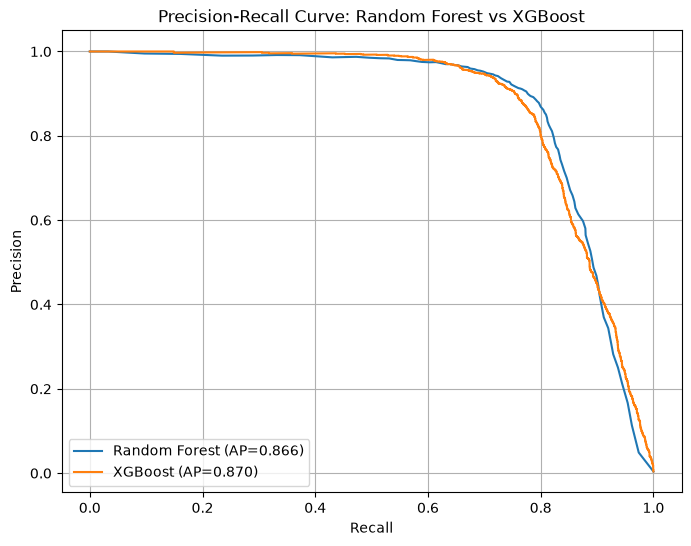

Saved as pr_curve.png


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probability scores (not hard predictions) for each model
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model_v2.predict_proba(X_test)[:, 1]  # the w=15 version

# Compute precision-recall curves
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_probs)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_probs)

# Compute Average Precision (single-number summary)
rf_ap = average_precision_score(y_test, rf_probs)
xgb_ap = average_precision_score(y_test, xgb_probs)

print(f"Random Forest AP: {rf_ap:.4f}")
print(f"XGBoost (w=15) AP: {xgb_ap:.4f}")

# Plot both curves together
plt.figure(figsize=(8, 6))
plt.plot(rf_recall, rf_precision, label=f'Random Forest (AP={rf_ap:.3f})')
plt.plot(xgb_recall, xgb_precision, label=f'XGBoost (AP={xgb_ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Random Forest vs XGBoost')
plt.legend()
plt.grid(True)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as pr_curve.png")

Framework — pick a minimum acceptable recall

In [36]:
from sklearn.metrics import  precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

target_recall = 0.80
idx = np.argmin(np.abs(recall - target_recall))
print(f"At recall= {recall[idx]:.3f},precision= {precision[idx]:.3f},thresholds = {thresholds[idx]:.3f}")

for target in [0.70, 0.75, 0.80, 0.85, 0.90]:
    idx = np.argmin(np.abs(recall - target))
    print(f"Target recall={target}: actual recall={recall[idx]:.3f}, precision={precision[idx]:.3f}, threshold={thresholds[idx]:.3f}")

At recall= 0.800,precision= 0.800,thresholds = 0.730
Target recall=0.7: actual recall=0.700, precision=0.947, threshold=0.943
Target recall=0.75: actual recall=0.750, precision=0.906, threshold=0.876
Target recall=0.8: actual recall=0.800, precision=0.800, threshold=0.730
Target recall=0.85: actual recall=0.850, precision=0.622, threshold=0.498
Target recall=0.9: actual recall=0.900, precision=0.448, threshold=0.267


Going from 70% → 80% recall costs you 14.7 points of precision (0.947 → 0.800). But going from 80% → 90% recall costs you 35 points (0.800 → 0.448). That's a steep cliff — the last 10% of fraud caught costs you enormously in false positives.

In [37]:
final_threshold = 0.730

y_pred_final = (xgb_probs > final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.80      0.80      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.90      0.90    555719
weighted avg       1.00      1.00      1.00    555719

[[553145    429]
 [   429   1716]]


Save your trained model and the exact feature list

In [38]:
import joblib
# Save the XGBoost model
joblib.dump(xgb_model_v2, 'fraud_model.pkl')
# Save the exact feature columns (and their order) the model expects
feature_column = X_train.columns.tolist()
joblib.dump(feature_column, 'feature_column.pkl')
# Save the final threshold we chose
joblib.dump(0.730, 'threshold.pkl')

print("Saved mdoel, features, and threshold")


Saved mdoel, features, and threshold
